In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [28]:
df=pd.read_csv('Processed_data.csv')
df

,Cycle,SensorMeasure11,SensorMeasure13,SensorMeasure4,SensorMeasure14,SensorMeasure15,SensorMeasure9,SensorMeasure8,SensorMeasure3,SensorMeasure17,...,OpSet2,SensorMeasure20,SensorMeasure21,OpSet1,SensorMeasure6,SensorMeasure10,SensorMeasure1,SensorMeasure5,SensorMeasure18,RUL
0,1,47.47,2388.02,1400.60,8138.62,8.4195,9046.19,2388.06,1589.70,392,...,-0.0004,39.06,23.4190,-0.0007,21.61,1.30,518.67,14.62,2388,320
1,2,47.49,2388.07,1403.14,8131.49,8.4318,9044.07,2388.04,1591.82,392,...,-0.0003,39.00,23.4236,0.0019,21.61,1.30,518.67,14.62,2388,319
2,3,47.27,2388.03,1404.20,8133.23,8.4178,9052.94,2388.08,1587.99,390,...,0.0003,38.95,23.3442,-0.0043,21.61,1.30,518.67,14.62,2388,318
3,4,47.13,2388.08,1401.87,8133.83,8.3682,9049.48,2388.11,1582.79,392,...,0.0000,38.88,23.3739,0.0007,21.61,1.30,518.67,14.62,2388,317
4,5,47.28,2388.04,1406.22,8133.80,8.4294,9055.15,2388.06,1582.85,393,...,-0.0002,38.90,23.4044,-0.0019,21.61,1.30,518.67,14.62,2388,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160354,251,46.08,2388.73,1315.28,8185.69,8.4541,8840.16,2319.66,1516.36,372,...,0.2500,29.11,17.5234,9.9998,15.46,1.27,489.05,10.52,2319,4
160355,252,48.04,2388.46,1426.77,8185.47,8.2221,9117.12,2388.47,1598.92,396,...,0.0015,39.38,23.7151,0.0028,21.57,1.31,518.67,14.62,2388,3
160356,253,48.24,2388.48,1430.56,8193.94,8.2525,9126.53,2388.51,1607.72,395,...,0.0000,39.78,23.8270,0.0029,21.57,1.31,518.67,14.62,2388,2
160357,254,42.53,2388.83,1148.18,8125.64,9.0515,8403.64,2223.78,1381.29,337,...,0.8400,15.26,9.0774,35.0046,7.96,1.05,449.44,5.48,2223,1


In [29]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# ----------------------------
# 1. Prepare data
# ----------------------------
X = df.drop('RUL', axis=1)
y = df['RUL']

# ----------------------------
# 2. Split 80% train, 20% remaining
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=False)

# Split remaining 20% → 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=False)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ----------------------------
# 3. Train Linear Regression
# ----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

# ----------------------------
# 4. Predict
# ----------------------------
y_pred_train = lr.predict(X_train)
y_pred_val   = lr.predict(X_val)
y_pred_test  = lr.predict(X_test)

# ----------------------------
# 5. Evaluate
# ----------------------------
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n=== {label} ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

# Training
evaluate(y_train, y_pred_train, "Training Set")

# Hyperparameter tuning set (Validation 10%)
evaluate(y_val, y_pred_val, "Validation Set (10%)")

# Final testing 10%
evaluate(y_test, y_pred_test, "Test Set (10%)")


Train: (128287, 22)
Validation: (16036, 22)
Test: (16036, 22)

=== Training Set ===
RMSE: 70.2378
MAE : 54.5878
R²  : 0.4695

=== Validation Set (10%) ===
RMSE: 65.7554
MAE : 54.7035
R²  : 0.5032

=== Test Set (10%) ===
RMSE: 63.0228
MAE : 53.6863
R²  : 0.4298


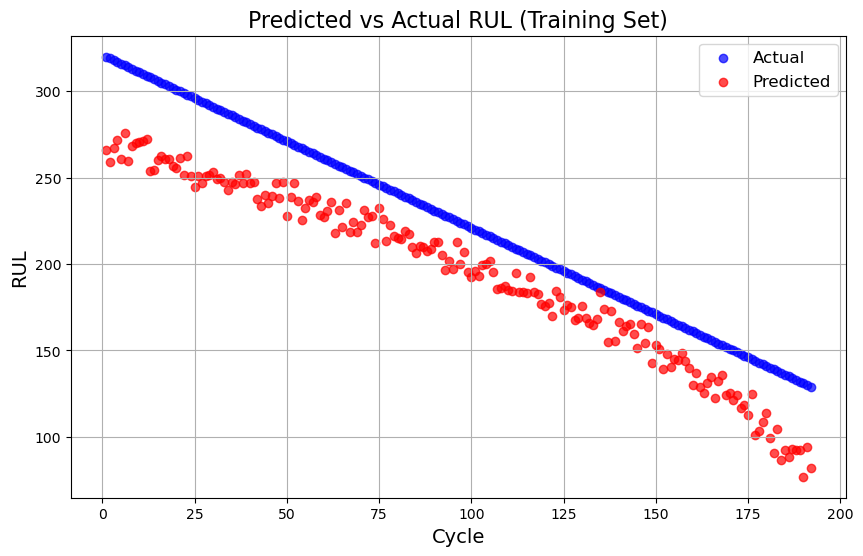

RMSE on Training set: 70.2378


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

# ------------------------------
# TRAINING SET PLOT
# ------------------------------
y_pred_train = lr.predict(X_train)

subset = slice(0, 192)

plt.figure(figsize=(10,6))
plt.scatter(
    X_train['Cycle'].iloc[subset], 
    y_train.iloc[subset], 
    color='blue', label='Actual', alpha=0.7
)
plt.scatter(
    X_train['Cycle'].iloc[subset], 
    y_pred_train[subset], 
    color='red', label='Predicted', alpha=0.7
)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('RUL', fontsize=14)
plt.title('Predicted vs Actual RUL (Training Set)', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()

# Training RMSE
rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
print(f'RMSE on Training set: {rmse_train:.4f}')



Test Set Metrics:
RMSE: 63.0228
MAE : 53.6863
R²  : 0.4298


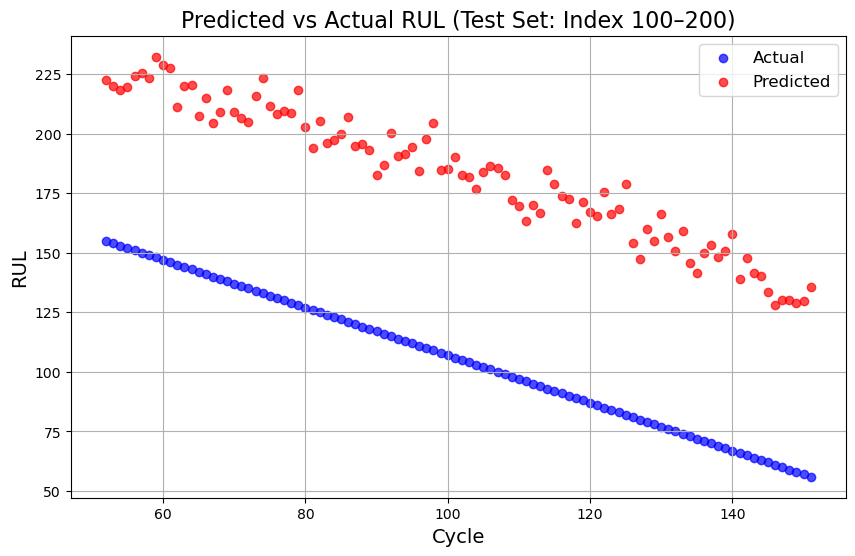

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

# ------------------------------
# TEST SET METRICS
# ------------------------------
y_pred_test = lr.predict(X_test)

rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
mae_test  = metrics.mean_absolute_error(y_test, y_pred_test)
r2_test   = metrics.r2_score(y_test, y_pred_test)

print("\nTest Set Metrics:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE : {mae_test:.4f}")
print(f"R²  : {r2_test:.4f}")

# ------------------------------
# TEST SET PLOT (Index 100–200)
# ------------------------------
start_idx = 100
end_idx   = 200

plt.figure(figsize=(10,6))
plt.scatter(
    X_test['Cycle'].iloc[start_idx:end_idx], 
    y_test.iloc[start_idx:end_idx],
    color='blue', label='Actual', alpha=0.7
)
plt.scatter(
    X_test['Cycle'].iloc[start_idx:end_idx], 
    y_pred_test[start_idx:end_idx],
    color='red', label='Predicted', alpha=0.7
)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('RUL', fontsize=14)
plt.title(f'Predicted vs Actual RUL (Test Set: Index {start_idx}–{end_idx})', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()


Train: (128287, 22)
Validation: (16036, 22)
Test: (16036, 22)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Hyperparameters: {'ridge__alpha': 0.0001}

===== Model Performance =====
Training: RMSE=70.2378, MAE=54.5879, R2=0.4695
Validation: RMSE=65.7539, MAE=54.7023, R2=0.5032
Test: RMSE=63.0210, MAE=53.6851, R2=0.4298


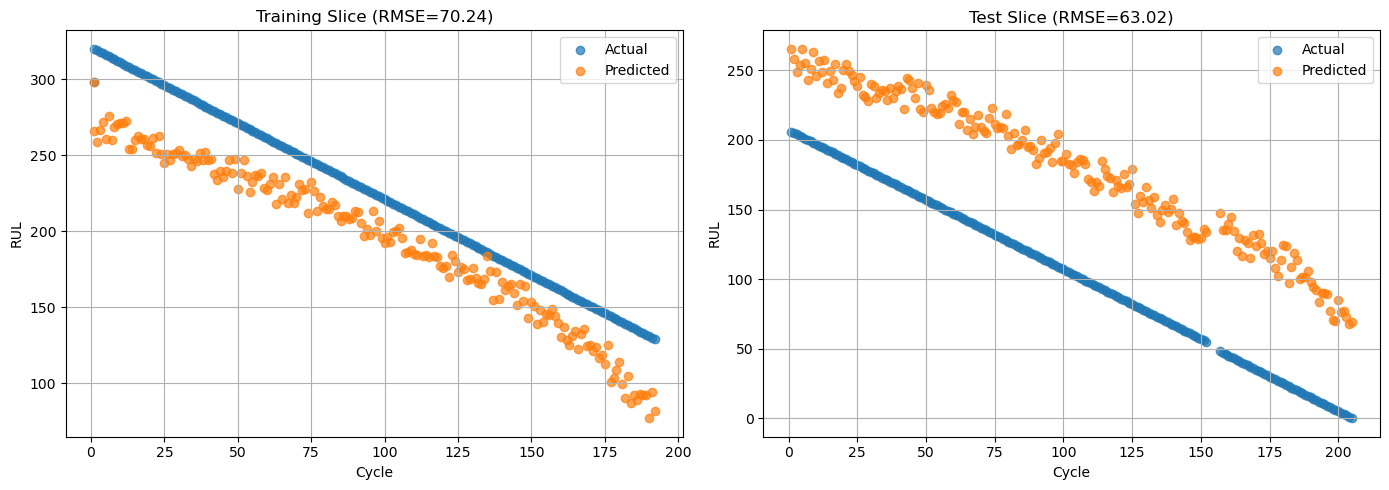

In [32]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ----------------------------
# 1. Prepare X, y
# ----------------------------
X = df.drop('RUL', axis=1)
y = df['RUL']

# ----------------------------
# 2. 80/10/10 Split (Time-Series Safe)
# ----------------------------
# First split: 80% train + 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, shuffle=False, random_state=42
)

# Second split: 10% validation + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ----------------------------
# 3. Pipeline: scaling + Ridge
# ----------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# ----------------------------
# 4. 10 Hyperparameters for Ridge
# ----------------------------
param_grid = {
    "ridge__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]   # 10 values
}

# ----------------------------
# 5. Time-series CV for tuning (only on training set)
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Hyperparameters:", grid.best_params_)

best_model = grid.best_estimator_

# ----------------------------
# 6. Predictions
# ----------------------------
y_train_pred = best_model.predict(X_train)
y_val_pred   = best_model.predict(X_val)
y_test_pred  = best_model.predict(X_test)

# ----------------------------
# 7. Evaluation Function
# ----------------------------
def evaluate(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")
    return rmse

print("\n===== Model Performance =====")
rmse_train = evaluate("Training", y_train, y_train_pred)
rmse_val   = evaluate("Validation", y_val, y_val_pred)
rmse_test  = evaluate("Test", y_test, y_test_pred)

# ----------------------------
# 8. Plots (Train + Test slices)
# ----------------------------
slice_train = slice(0, 193)
slice_test = slice(0, 201)

plt.figure(figsize=(14,5))

# ---- TRAINING PLOT ----
plt.subplot(1,2,1)
plt.scatter(X_train['Cycle'].iloc[slice_train], y_train.iloc[slice_train], label='Actual', alpha=0.7)
plt.scatter(X_train['Cycle'].iloc[slice_train], y_train_pred[slice_train], label='Predicted', alpha=0.7)
plt.title(f'Training Slice (RMSE={rmse_train:.2f})')
plt.xlabel("Cycle"); plt.ylabel("RUL")
plt.legend(); plt.grid(True)

# ---- TEST PLOT ----
plt.subplot(1,2,2)
plt.scatter(X_test['Cycle'].iloc[slice_test], y_test.iloc[slice_test], label='Actual', alpha=0.7)
plt.scatter(X_test['Cycle'].iloc[slice_test], y_test_pred[slice_test], label='Predicted', alpha=0.7)
plt.title(f'Test Slice (RMSE={rmse_test:.2f})')
plt.xlabel("Cycle"); plt.ylabel("RUL")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit

# ----------------------------
# 1. Prepare data
# ----------------------------
X = df.drop("RUL", axis=1)
y = df["RUL"]

# ----------------------------
# 2. 80/10/10 Split
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, shuffle=False, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ----------------------------
# 3. **Optimized Hyperparameter Grid (fast)**
# ----------------------------
param_grid = {
    "n_estimators": [40, 80],     
    "max_depth": [10, 15],         
    "min_samples_split": [2, 5]    # same
}
# Total combos = 2 × 2 × 2 = **8** instead of 32

tscv = TimeSeriesSplit(n_splits=3)  # was 5 folds → now 3 folds (40% faster)

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=2),  # n_jobs=-1 slows laptop!
    param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=2,
    verbose=1
)

# ----------------------------
# 4. Train RF (this will be 10× faster)
# ----------------------------
grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)

best_rf = grid.best_estimator_

# ----------------------------
# 5. Predict
# ----------------------------
y_train_pred = best_rf.predict(X_train)
y_val_pred   = best_rf.predict(X_val)
y_test_pred  = best_rf.predict(X_test)

# ----------------------------
# 6. Evaluation
# ----------------------------
def evaluate(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"{label}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

print("\n===== Model Evaluation =====")
evaluate("Training", y_train, y_train_pred)
evaluate("Validation", y_val, y_val_pred)
evaluate("Test", y_test, y_test_pred)


Train: (128287, 22)
Validation: (16036, 22)
Test: (16036, 22)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 40}

===== Model Evaluation =====
Training: RMSE=64.9539, MAE=49.8646, R2=0.5463
Validation: RMSE=62.2756, MAE=49.7840, R2=0.5544
Test: RMSE=60.0926, MAE=51.2736, R2=0.4816


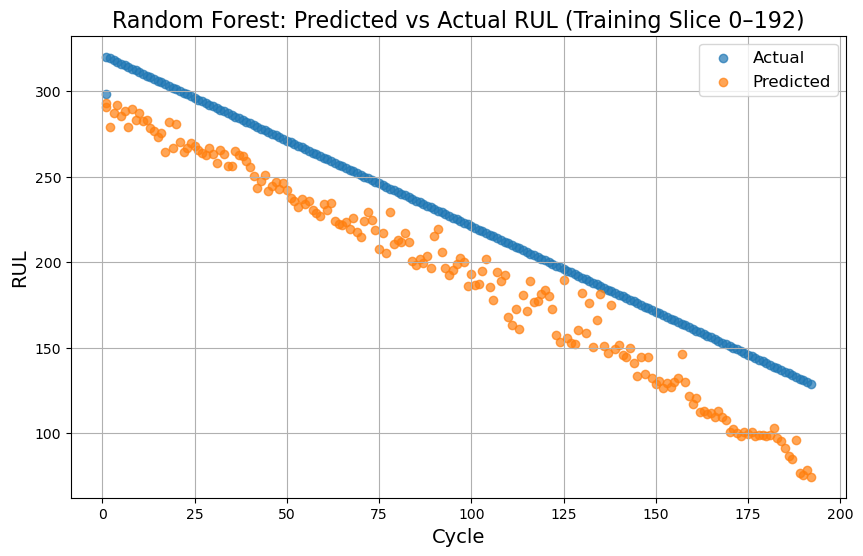

RMSE on Training slice (0–192): 33.6601


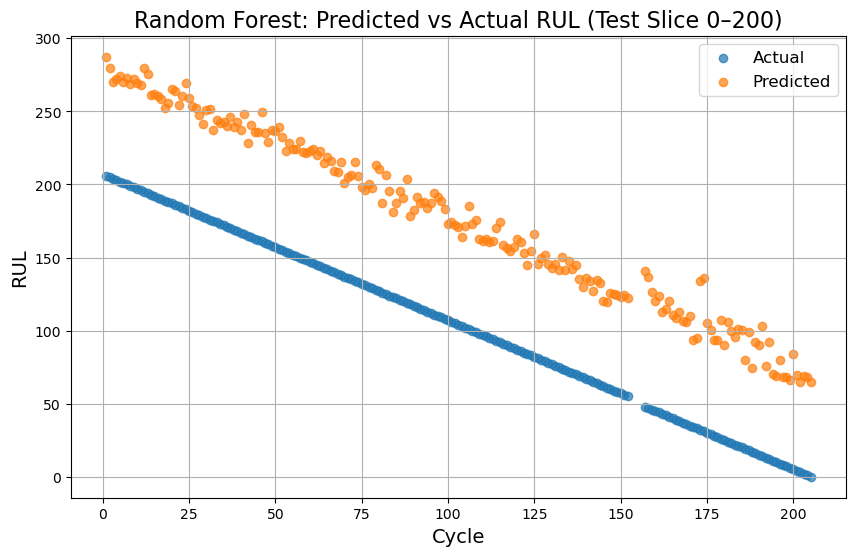

RMSE on Test slice (0–200): 72.4236


In [34]:
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np

# Predict on training set using Random Forest
y_train_pred = best_rf.predict(X_train)

# Select slice
train_slice = slice(0, 193)  # indices 0 to 192

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X_train['Cycle'].iloc[train_slice], y_train.iloc[train_slice],
            label='Actual', alpha=0.7)
plt.scatter(X_train['Cycle'].iloc[train_slice], y_train_pred[train_slice],
            label='Predicted', alpha=0.7)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('RUL', fontsize=14)
plt.title('Random Forest: Predicted vs Actual RUL (Training Slice 0–192)', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()

# RMSE for training slice
rmse_train_slice = np.sqrt(metrics.mean_squared_error(
    y_train.iloc[train_slice], y_train_pred[train_slice]
))
print(f'RMSE on Training slice (0–192): {rmse_train_slice:.4f}')


# ------------------- TEST SET ----------------------

# Predict on test set
y_test_pred = best_rf.predict(X_test)

# Select slice
test_slice = slice(0, 201)  # indices 0 to 200

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X_test['Cycle'].iloc[test_slice], y_test.iloc[test_slice],
            label='Actual', alpha=0.7)
plt.scatter(X_test['Cycle'].iloc[test_slice], y_test_pred[test_slice],
            label='Predicted', alpha=0.7)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('RUL', fontsize=14)
plt.title('Random Forest: Predicted vs Actual RUL (Test Slice 0–200)', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()

# RMSE for test slice
rmse_test_slice = np.sqrt(metrics.mean_squared_error(
    y_test.iloc[test_slice], y_test_pred[test_slice]
))
print(f'RMSE on Test slice (0–200): {rmse_test_slice:.4f}')


In [35]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit

# ----------------------------
# 1. Prepare data
# ----------------------------
X = df.drop("RUL", axis=1)
y = df["RUL"]

# ----------------------------
# 2. 80/10/10 Split
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, shuffle=False, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ----------------------------
# 3. Gradient Boosting Hyperparameters (FAST tuning)
# ----------------------------
param_grid = {
    "n_estimators": [100, 200],    # 2
    "learning_rate": [0.05, 0.1],  # 2
    "max_depth": [2, 3]            # 2
}
# Total combos = 2 × 2 × 2 = **8** (very fast + useful)

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1
)

# ----------------------------
# 4. Train using CV tuning
# ----------------------------
grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)
best_gbr = grid.best_estimator_

# ----------------------------
# 5. Predictions
# ----------------------------
y_train_pred = best_gbr.predict(X_train)
y_val_pred   = best_gbr.predict(X_val)
y_test_pred  = best_gbr.predict(X_test)

# ----------------------------
# 6. Evaluation
# ----------------------------
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

print("\n===== Model Performance =====")
evaluate("Training", y_train, y_train_pred)
evaluate("Validation", y_val, y_val_pred)
evaluate("Test", y_test, y_test_pred)


Train: (128287, 22)
Validation: (16036, 22)
Test: (16036, 22)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

===== Model Performance =====
Training: RMSE=68.1833, MAE=52.4430, R2=0.5001
Validation: RMSE=62.3091, MAE=49.9387, R2=0.5539
Test: RMSE=59.8619, MAE=51.3850, R2=0.4856


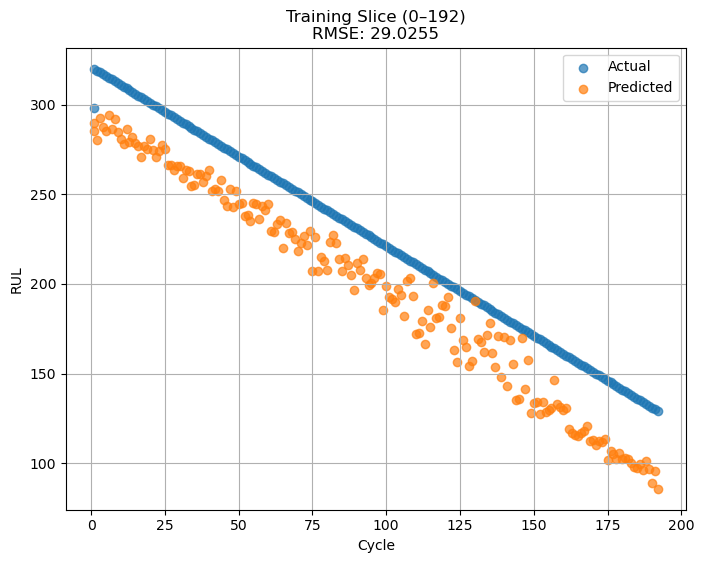

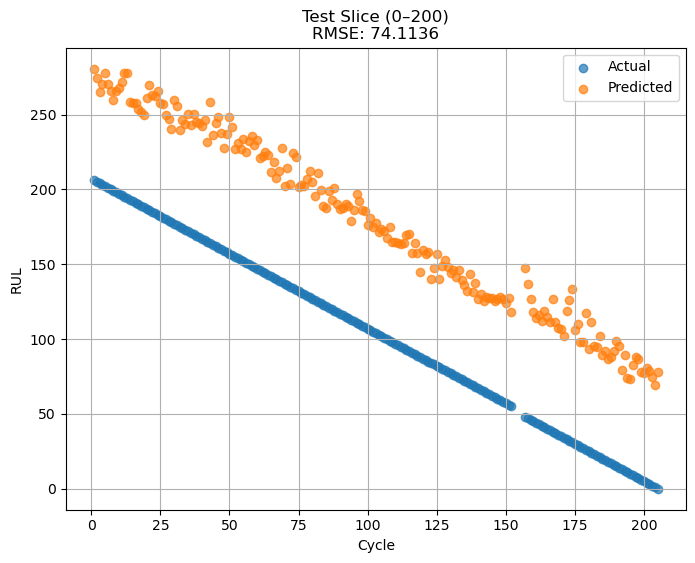

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict using trained Gradient Boosting model
y_train_pred = best_gbr.predict(X_train)
y_test_pred  = best_gbr.predict(X_test)

# Select slices
train_slice = slice(0, 193)  # 0 to 192
test_slice  = slice(0, 201)  # 0 to 200

# RMSE values for slices
rmse_train_slice = np.sqrt(mean_squared_error(y_train.iloc[train_slice], y_train_pred[train_slice]))
rmse_test_slice  = np.sqrt(mean_squared_error(y_test.iloc[test_slice], y_test_pred[test_slice]))

# ----------------------------
# Plot 1 – Training slice
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_train['Cycle'].iloc[train_slice], y_train.iloc[train_slice], label='Actual', alpha=0.7)
plt.scatter(X_train['Cycle'].iloc[train_slice], y_train_pred[train_slice], label='Predicted', alpha=0.7)
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title(f'Training Slice (0–192)\nRMSE: {rmse_train_slice:.4f}')
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2 – Test slice
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_test['Cycle'].iloc[test_slice], y_test.iloc[test_slice], label='Actual', alpha=0.7)
plt.scatter(X_test['Cycle'].iloc[test_slice], y_test_pred[test_slice], label='Predicted', alpha=0.7)
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title(f'Test Slice (0–200)\nRMSE: {rmse_test_slice:.4f}')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ----------------------------
# 1. Prepare data
# ----------------------------
X = df.drop("RUL", axis=1)
y = df["RUL"]

# ----------------------------
# 2. 80/10/10 Split
# ----------------------------
X_train80, X_temp20, y_train80, y_temp20 = train_test_split(
    X, y, test_size=0.20, shuffle=False, random_state=42
)

X_val10, X_test10, y_val10, y_test10 = train_test_split(
    X_temp20, y_temp20, test_size=0.50, shuffle=False, random_state=42
)

print("Train:", X_train80.shape)
print("Validation:", X_val10.shape)
print("Test:", X_test10.shape)

# ----------------------------
# 3. FAST Hyperparameter Grid (16 combinations)
# ----------------------------
param_grid = {
    "n_estimators": [100, 200],          # 2 values
    "max_depth": [3, 5],                 # 2 values
    "learning_rate": [0.05, 0.1],        # 2 values
    "subsample": [0.8, 1.0]              # 2 values
}
# Total = 2 × 2 × 2 × 2 = **16 combinations**

tscv = TimeSeriesSplit(n_splits=3)  # Faster than 5 splits

grid = GridSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

# ----------------------------
# 4. FAST tuning on 10% validation data
# ----------------------------
grid.fit(X_val10, y_val10)

print("\nBest Parameters:")
print(grid.best_params_)

best_xgb = grid.best_estimator_

# ----------------------------
# 5. Train final model on 80% data
# ----------------------------
best_xgb.fit(X_train80, y_train80)

# ----------------------------
# 6. Predictions
# ----------------------------
y_train_pred = best_xgb.predict(X_train80)
y_test_pred  = best_xgb.predict(X_test10)

# ----------------------------
# 7. Evaluation
# ----------------------------
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

print("\n===== RESULTS =====")
evaluate("Train (80%)", y_train80, y_train_pred)
evaluate("Test (10%)", y_test10, y_test_pred)


Train: (128287, 22)
Validation: (16036, 22)
Test: (16036, 22)
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

===== RESULTS =====
Train (80%): RMSE=68.1787, MAE=52.4131, R2=0.5001
Test (10%): RMSE=59.6524, MAE=51.2243, R2=0.4891


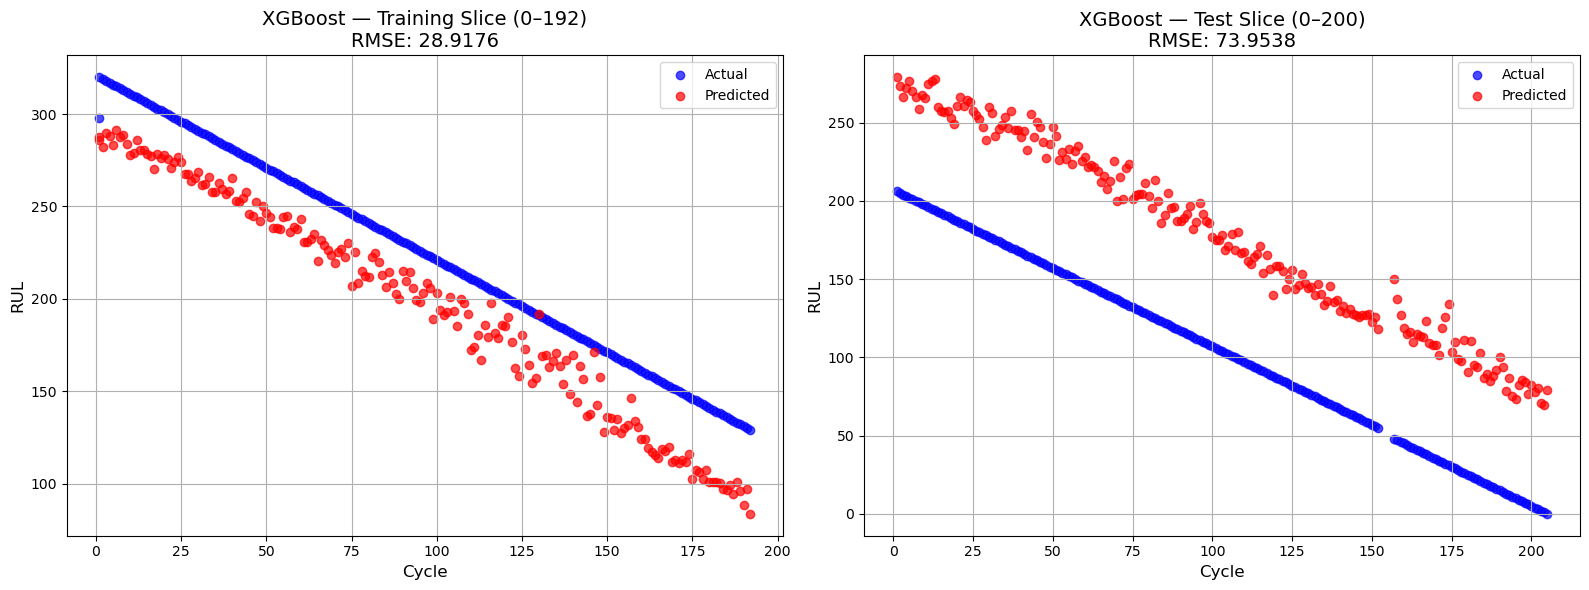

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# -------------------------------------------------
# PREDICT USING TRAINED XGBoost MODEL
# -------------------------------------------------
y_train_pred = best_xgb.predict(X_train80)
y_test_pred  = best_xgb.predict(X_test10)

# -------------------------------------------------
# SLICES FOR VISUALIZATION (same as before)
# -------------------------------------------------
train_slice = slice(0, 193)   # indices 0–192
test_slice  = slice(0, 201)   # indices 0–200

# -------------------------------------------------
# RMSE CALCULATION FOR THESE SLICES
# -------------------------------------------------
rmse_train_slice = np.sqrt(
    mean_squared_error(y_train80.iloc[train_slice],
                       y_train_pred[train_slice])
)

rmse_test_slice = np.sqrt(
    mean_squared_error(y_test10.iloc[test_slice],
                       y_test_pred[test_slice])
)

# -------------------------------------------------
# PLOT TRAINING & TEST SIDE BY SIDE
# -------------------------------------------------
plt.figure(figsize=(16,6))

# ========= TRAINING PLOT =========
plt.subplot(1, 2, 1)
plt.scatter(
    X_train80['Cycle'].iloc[train_slice],
    y_train80.iloc[train_slice],
    color='blue', alpha=0.7, label='Actual'
)
plt.scatter(
    X_train80['Cycle'].iloc[train_slice],
    y_train_pred[train_slice],
    color='red', alpha=0.7, label='Predicted'
)
plt.xlabel("Cycle", fontsize=12)
plt.ylabel("RUL", fontsize=12)
plt.title(f"XGBoost — Training Slice (0–192)\nRMSE: {rmse_train_slice:.4f}", fontsize=14)
plt.legend()
plt.grid(True)

# ========= TEST PLOT =========
plt.subplot(1, 2, 2)
plt.scatter(
    X_test10['Cycle'].iloc[test_slice],
    y_test10.iloc[test_slice],
    color='blue', alpha=0.7, label='Actual'
)
plt.scatter(
    X_test10['Cycle'].iloc[test_slice],
    y_test_pred[test_slice],
    color='red', alpha=0.7, label='Predicted'
)
plt.xlabel("Cycle", fontsize=12)
plt.ylabel("RUL", fontsize=12)
plt.title(f"XGBoost — Test Slice (0–200)\nRMSE: {rmse_test_slice:.4f}", fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [39]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "RMSE": ["63.0228", "63.0210", "60.0926", "59.8619", "59.6524"],
    "MAE": ["53.6863", "53.6851", "51.2736", "51.3850", "51.2243"],
    "R2 Score": ["0.4298", "0.4298", "0.4816", "0.4856", "0.4891"]
})

results_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,63.0228,53.6863,0.4298
1,Ridge Regression,63.0210,53.6851,0.4298
2,Random Forest,60.0926,51.2736,0.4816
3,Gradient Boosting,59.8619,51.3850,0.4856
4,XGBoost,59.6524,51.2243,0.4891


In [40]:
best_model_row = results_df.loc[results_df["RMSE"].idxmin()]

best_model_name = best_model_row["Model"]
best_rmse = best_model_row["RMSE"]
best_mae = best_model_row["MAE"]
best_r2 = best_model_row["R2 Score"]

print("\n=== BEST MODEL (Based on Lowest RMSE) ===")
print(f"Model: {best_model_name}")
print(f"RMSE: {best_rmse}")
print(f"MAE: {best_mae}")
print(f"R² Score: {best_r2}")


=== BEST MODEL (Based on Lowest RMSE) ===
Model: XGBoost
RMSE: 59.6524
MAE: 51.2243
R² Score: 0.4891


Text(0, 0.5, 'RMSE')

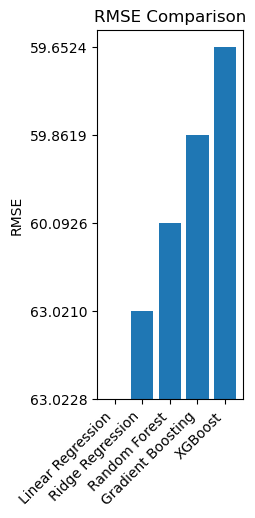

In [41]:
# RMSE Plot
plt.subplot(1,3,1)
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha='right')
plt.title("RMSE Comparison")
plt.ylabel("RMSE")


Text(0, 0.5, 'MAE')

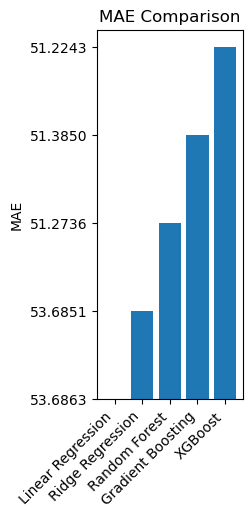

In [42]:
# MAE Plot
plt.subplot(1,3,2)
plt.bar(results_df["Model"], results_df["MAE"])
plt.xticks(rotation=45, ha='right')
plt.title("MAE Comparison")
plt.ylabel("MAE")
